In [1]:
import sys
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.append(str(Path.cwd().parent / 'scripts'))
from _tyndp_helpers import _extract_scenario_values, _extract_scenario_values_rowwise

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [12]:
networks = [
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT_+0.00.nc',
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc',
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.3.nc',
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_-0.3.nc',
]

In [92]:
def extract_wiggle(network_path):
    """Extract cost variation string (e.g., '+0.00', '-0.3') from network filename"""
    filename = network_path.name
    # Find pattern like +0.00.nc or -0.3.nc
    import re
    match = re.search(r'([+-]\d+\.\d+)\.nc$', filename)
    return float(match.group(1)) if match else 0.0


# Sort networks by year (2025, 2030, 2035, etc.)
def extract_year(network_path):
    """Extract year from network filename"""
    filename = network_path.name
    # Find year pattern like _2030_, _2035_, etc.

    assert '_2025_' in filename or '_2030_' in filename or '_2035_' in filename, f"Model must have planning horizon 2025, 2030 or 2035"
    import re
    match = re.search(r'_(\d{4})_', filename)
    return int(match.group(1)) if match else 0

ns = sorted(networks, key=lambda x: (extract_year(x), extract_wiggle(x)))

In [94]:
for n_fn in ns:
    n = pypsa.Network(n_fn)
    break

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_-0.3.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [95]:
eu27_countries = [
    "AT", "BE", "BG", "HR", "CY", "CZ", "DK", "EE", "FI", "FR", "DE", "GR", "HU",
    "IE", "IT", "LV", "LT", "LU", "MT", "NL", "PL", "PT", "RO", "SK", "SI", "ES", "SE",
]

def get_industry_gas_consumption(n):
    
    fixed_demand = n.loads.loc[n.loads.carrier.isin(['gas for industry', 'gas for industry CC']), ['p_set']]

    fixed_demand = fixed_demand.loc[fixed_demand.index.str.startswith(tuple(eu27_countries))]
    w = n.snapshot_weightings['generators']

    fixed_demand = w.sum() * fixed_demand.sum()
    print('Warning! Does not yet consider gas boilers in industry')

    ls = n.links.index[
            n.links.carrier.isin(['SMR', 'SMR CC']) &
            n.links.index.str.startswith(tuple(eu27_countries))
        ]
    
    varying_demand = n.links_t.p0.loc[:, ls].sum(axis=1).mul(w, axis=0).sum() / 1e6

    return fixed_demand.sum() / 1e6 + varying_demand


def get_electricity_gas_consumption(n):
    
    w = n.snapshot_weightings['generators']

    ls = n.links.index[n.links.carrier.isin(['CCGT', 'OCGT', 'urban central gas CHP', 'urban central gas CHP CC'])]
    ls = ls[ls.str.startswith(tuple(eu27_countries))]

    return n.links_t.p0.loc[:, ls].sum(axis=1).mul(w, axis=0).sum() / 1e6


def get_heating_gas_consumption(n):
    
    w = n.snapshot_weightings['generators']

    ls = n.links.index[(
            n.links.carrier.str.contains('gas boiler') &
            n.links.index.str.startswith(tuple(eu27_countries)) &
            n.links.bus1.str.contains('|'.join(['rural', 'urban']))
        )]

    return n.links_t.p0.loc[:, ls].sum(axis=1).mul(w, axis=0).sum() / 1e6


ind = get_industry_gas_consumption(n)
elec = get_electricity_gas_consumption(n)
heat = get_heating_gas_consumption(n)

Warning! Does not yet consider gas boilers in industry


INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_-0.3.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Warning! Does not yet consider gas boilers in industry


INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Warning! Does not yet consider gas boilers in industry


INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.3.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Warning! Does not yet consider gas boilers in industry


FileNotFoundError: [Errno 2] No such file or directory: '/home/lukas/Desktop/res/v1/pypsa-eur/results/networks/base_s_50__168H-T-H-B-I-A-dist1_2035_NT_+0.00.nc'

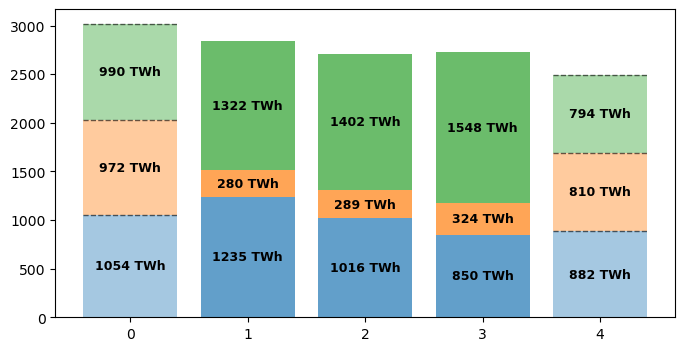

In [ ]:

idx = pd.IndexSlice
stats = n.statistics.energy_balance().loc[idx[:,:,'gas']]
stats = stats.loc[stats < 0].abs() / 1e6

eu27_gas_consumption = {
    "Residential&Tertiary": {2019: 1402, 2030: 990, 2040: 599},
    "Industry": {2019: 1034, 2030: 888, 2040: 596},
    "Power Generation": {2019: 1218, 2030: 972, 2040: 649},
    "Non-energy use": {2019: 178, 2030: 166, 2040: 114},
    "Total": {2019: 3918, 2030: 3368, 2040: 2328},
}


fig, ax = plt.subplots(figsize=(len(ns) * 2, 4))

# Model year - change this to match your model
model_years = [extract_year(n) for n in ns]

# Get reference values for the model year
def get_reference_value(category, year):
    if year in eu27_gas_consumption[category]:
        return eu27_gas_consumption[category][year]
    elif year == 2035:  # Interpolate between 2030 and 2040
        val_2030 = eu27_gas_consumption[category][2030]
        val_2040 = eu27_gas_consumption[category][2040]
        return val_2030 + (val_2040 - val_2030) * 0.5
    else:
        raise ValueError(f"No reference data available for year {year}")

# Create stacked bar plot
categories = ['Industry + Non-energy', 'Power Generation', 'Residential & Tertiary']
nice_names = ['Industry', 'Power Generation', 'Heating']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bar_width = 0.8

previous_year = None
x_position = 0
x_tick_labels = []
added_labels = False

for n_fn, year in zip(ns, model_years):

    if year != previous_year:

        # Reference values
        ref_industry = get_reference_value("Industry", year) + get_reference_value("Non-energy use", year)
        ref_power = get_reference_value("Power Generation", year)
        ref_residential = get_reference_value("Residential&Tertiary", year)
        ref_values = [ref_industry, ref_power, ref_residential]

        previous_year = year

        x_tick_labels.append(f'TYNDP Reference {year}')

        # Plot stacked bars for reference
        bottom_ref = 0
        for i, (value, color, category) in enumerate(zip(ref_values, colors, categories)):
            ax.bar(x_position, value, bar_width, bottom=bottom_ref, 
                color=color, alpha=0.4)
            # Add horizontal line extending to model bar
            ax.text(x_position, bottom_ref + value/2, f'{value:.0f} TWh',
                    ha='center', va='center', fontweight='bold', fontsize=9)
            ax.hlines(bottom_ref + value, x_position - bar_width/2, x_position + bar_width/2,
                    colors='k', linestyles='--', alpha=0.6, linewidth=1)
            bottom_ref += value

        x_position += 1
    
    n = pypsa.Network(n_fn)
    wiggle = extract_wiggle(n_fn)

    ind = get_industry_gas_consumption(n)
    elec = get_electricity_gas_consumption(n)
    heat = get_heating_gas_consumption(n)

    model_values = [ind, elec, heat]

    bottom_model = 0
    for i, (value, color, category) in enumerate(zip(model_values, colors, categories)):
        if not added_labels:
            kwargs = {'label': nice_names[i]}
        else:
            kwargs = {}
        bar = ax.bar(x_position, value, bar_width, bottom=bottom_model,
                    color=color, alpha=0.7, **kwargs)
        # Add value label
        ax.text(x_position, bottom_model + value/2, f'{value:.0f} TWh',
                ha='center', va='center', fontweight='bold', fontsize=9)
        bottom_model += value

    added_labels = True

    x_position += 1
    x_tick_labels.append(f'Model {year} {wiggle}')

# Formatting
ax.set_xticks(range(len(x_tick_labels)))
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')
ax.set_ylabel('Gas Consumption (TWh/a)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(-0.5, len(x_tick_labels) - 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [62]:
heat

1402.098536941556

In [64]:
heat + elec + ind

2707.3318109871752

In [60]:
idx = pd.IndexSlice
stats = n.statistics.energy_balance().loc[idx[:,:,'gas']]
consumers = stats.loc[stats < 0].abs() / 1e6
consumers

component  carrier                   
Link       Combined-Cycle Gas             117.727187
           Open-Cycle Gas                   1.523799
           SMR                             14.145406
           SMR CC                         266.914330
           gas for industry              1046.209186
           gas for industry CC              0.023127
           rural gas boiler                91.613572
           urban central gas CHP          191.339496
           urban central gas CHP CC         0.008042
           urban central gas boiler       291.602055
           urban decentral gas boiler    1062.806191
dtype: float64

In [39]:
n.links.loc[n.links.carrier == 'urban central gas CHP']

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,underground,dc,reversed,geometry,location,under_construction,underwater_fraction,length_original,voltage,tags
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 urban central gas CHP,AL0 0 gas,AL0 0,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
AT0 0 urban central gas CHP,AT0 0 gas,AT0 0,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
BA0 0 urban central gas CHP,BA0 0 gas,BA0 0,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
BE0 0 urban central gas CHP,BE0 0 gas,BE0 0,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
BG0 0 urban central gas CHP,BG0 0 gas,BG0 0,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
CH0 0 urban central gas CHP,CH0 0 gas,CH0 0,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
CZ0 0 urban central gas CHP,CZ0 0 gas,CZ0 0,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
DE0 0 urban central gas CHP,DE0 0 gas,DE0 0,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
DE0 1 urban central gas CHP,DE0 1 gas,DE0 1,,urban central gas CHP,0.405,True,0,25.0,0.0,0.0,...,NaN,NaN,False,,,NaN,NaN,0.0,NaN,
